# OCR model for Reading Images of Text Captchas

**Credit:** Adapted from the Keras example [OCR model for reading Captchas](https://keras.io/examples/vision/captcha_ocr/), with a hyperparameter search added on top.

**Changes from `text_captcha_ocr.ipynb`:**

- The data is split into train, validation and test sets with a fixed seed. The test set is only used for the final evaluation.
- Results are reported as exact-match accuracy and character error rate, and compared against the unmodified keras.io model trained on the same split.
- Each search trial stops early. The search only tunes settings that matter: learning rate, layer sizes, dropout, a third conv block and data augmentation.
- The best settings are retrained from scratch instead of continuing training with a reset optimizer.
- CTC loss and decoding use `keras.ops.ctc_loss` and `keras.ops.ctc_decode` instead of hand-written `tf.compat.v1` code.
- The model adds batch normalization and a cosine learning-rate schedule.
- The dataset downloads to a relative `data/` folder, and the trained model is saved.

## Introduction

This example demonstrates a simple OCR model built with the Functional API. Apart from
combining CNN and RNN, it also illustrates how you can instantiate a new layer
and use it as an "Endpoint layer" for implementing CTC loss. For a detailed
guide to layer subclassing, please check out
[this page](https://keras.io/guides/making_new_layers_and_models_via_subclassing/)
in the developer guides.

## Setup

In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import json
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
import keras_tuner as kt
from keras import ops
from keras import layers

# Fixes the data split, weight initialization, augmentation and the tuner's choices
SEED = 42
keras.utils.set_random_seed(SEED)

## Load the data: [Captcha Images](https://www.kaggle.com/fournierp/captcha-version-2-images)
Let's download the data, unless it is already there. Set the `CAPTCHA_DATA_ROOT`
environment variable to use a copy stored somewhere else.

In [2]:
DATA_URL = "https://github.com/AakashKumarNain/CaptchaCracker/raw/master/captcha_images_v2.zip"

data_root = Path(os.environ.get("CAPTCHA_DATA_ROOT", "data"))
# The zip holds a single top-level captcha_images_v2/ folder
data_dir = data_root / "captcha_images_v2"

if not any(data_dir.glob("*.png")):
    data_root.mkdir(parents=True, exist_ok=True)
    zip_path = data_root / "captcha_images_v2.zip"
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(data_root)
    zip_path.unlink()

The dataset contains 1040 captcha files as `png` images. The label for each sample is a string,
the name of the file (minus the file extension).
We will map each character in the string to an integer for training the model. Similarly,
we will need to map the predictions of the model back to strings. For this purpose
we will maintain two dictionaries, mapping characters to integers, and integers to characters,
respectively.

In [3]:
# Get list of all the images; each label is the file name minus the extension
images = sorted(str(path) for path in data_dir.glob("*.png"))
assert images, f"No images found in {data_dir}"
labels = [Path(path).stem for path in images]
characters = sorted(set("".join(labels)))

print("Number of images found: ", len(images))
print("Number of labels found: ", len(labels))
print("Label lengths: ", sorted(set(map(len, labels))))
print("Number of unique characters: ", len(characters))
print("Characters present: ", characters)

# Batch size for training and validation
batch_size = 16

# Desired image dimensions
img_width = 200
img_height = 50

# Maximum training epochs; early stopping usually ends training sooner
epochs = 100

Number of images found:  1040
Number of labels found:  1040
Label lengths:  [5]
Number of unique characters:  19
Characters present:  ['2', '3', '4', '5', '6', '7', '8', 'b', 'c', 'd', 'e', 'f', 'g', 'm', 'n', 'p', 'w', 'x', 'y']


## Preprocessing

The data is split three ways. The validation set chooses the hyperparameters and the
stopping epoch, so its scores are optimistic. The test set is held back for the final evaluation.

In [4]:
# Mapping characters to integers. Index 0 is the out-of-vocabulary token "[UNK]",
# which no real character maps to, so it doubles as the label padding value.
char_to_num = layers.StringLookup(vocabulary=characters, mask_token=None)

# Mapping integers back to original characters
num_to_char = layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True
)

# The model scores every vocabulary entry plus the CTC "blank", which goes last
num_classes = len(char_to_num.get_vocabulary()) + 1
blank_index = num_classes - 1


def split_data(images, labels, train_size=0.8, valid_size=0.1, seed=SEED):
    # 1. Shuffle the indices once, with a fixed seed so every run gets the same split
    indices = np.random.default_rng(seed).permutation(len(images))
    # 2. Cut them into training, validation and test sets
    n_train = int(len(images) * train_size)
    n_valid = int(len(images) * valid_size)
    splits = np.split(indices, [n_train, n_train + n_valid])
    return [(images[idx], labels[idx]) for idx in splits]


(x_train, y_train), (x_valid, y_valid), (x_test, y_test) = split_data(
    np.array(images), np.array(labels)
)
print(f"Train: {len(x_train)}  Validation: {len(x_valid)}  Test: {len(x_test)}")


def encode_single_sample(img_path, label):
    # 1. Read image
    img = tf.io.read_file(img_path)
    # 2. Decode and convert to grayscale
    img = tf.io.decode_png(img, channels=1)
    # 3. Convert to float32 in [0, 1] range
    img = tf.image.convert_image_dtype(img, tf.float32)
    # 4. Resize to the desired size
    img = ops.image.resize(img, [img_height, img_width])
    # 5. Transpose the image because we want the time
    # dimension to correspond to the width of the image.
    img = ops.transpose(img, axes=[1, 0, 2])
    # 6. Map the characters in label to numbers
    label = char_to_num(tf.strings.unicode_split(label, input_encoding="UTF-8"))
    # 7. Return a dict as our model is expecting two inputs
    return {"image": img, "label": label}


def indices_to_text(indices):
    # Drop label padding (0) and the decoder's fill value (-1), then map back to characters
    indices = tf.boolean_mask(indices, indices > 0)
    return tf.strings.reduce_join(num_to_char(indices)).numpy().decode("utf-8")

Train: 832  Validation: 104  Test: 104


## Create `Dataset` objects

In [5]:
def make_dataset(x, y, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        # A different order every epoch
        dataset = dataset.shuffle(len(x), seed=SEED, reshuffle_each_iteration=True)
    return (
        dataset.map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
        # Pads shorter labels with 0 ("[UNK]") if a batch mixes label lengths
        .padded_batch(batch_size)
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )


train_dataset = make_dataset(x_train, y_train, shuffle=True)
validation_dataset = make_dataset(x_valid, y_valid)
test_dataset = make_dataset(x_test, y_test)

## Visualize the data

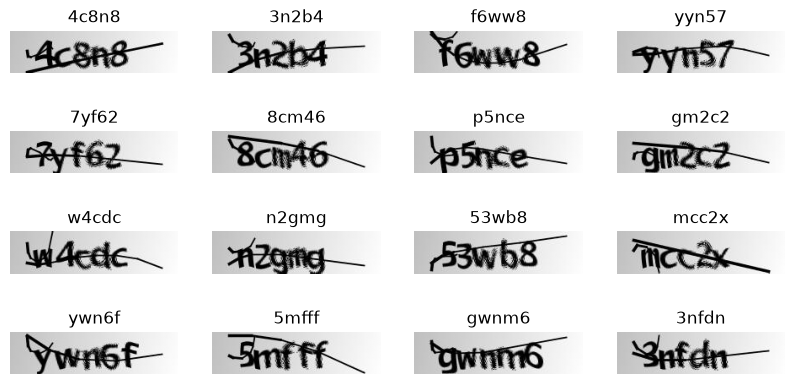

In [6]:
_, ax = plt.subplots(4, 4, figsize=(10, 5))
for batch in train_dataset.take(1):
    batch_images = batch["image"]
    batch_labels = batch["label"]
    for i in range(16):
        img = (batch_images[i] * 255).numpy().astype("uint8")
        label = indices_to_text(batch_labels[i])
        ax[i // 4, i % 4].imshow(img[:, :, 0].T, cmap="gray")
        ax[i // 4, i % 4].set_title(label)
        ax[i // 4, i % 4].axis("off")
plt.show()

## Model

`CTCLayer` computes the CTC loss with `keras.ops.ctc_loss`. That function expects raw
scores (logits), so the model's last layer has no activation. Keras' CTC ops treat index 0
as the blank by default, but index 0 is `[UNK]` here, so the blank index is passed
explicitly.

With only 832 training images, random augmentation might help the model generalize. It
only runs during training. In a test run, though, it roughly tripled the number of epochs
before the loss left CTC's initial plateau, where the model predicts nothing but blanks.
So the search decides whether to use it.

In [7]:
class CTCLayer(layers.Layer):
    def call(self, y_true, y_pred):
        # Each label's real length; padded positions hold 0 ("[UNK]")
        label_length = ops.sum(ops.cast(ops.not_equal(y_true, 0), "int32"), axis=-1)
        # Every image produces the same number of time steps
        batch_len = ops.shape(y_pred)[0]
        input_length = ops.full((batch_len,), ops.shape(y_pred)[1], dtype="int32")

        # Compute the training-time loss value and add it to the layer using
        # `self.add_loss()`. Keras sums added losses, so average over the batch first.
        loss = ops.ctc_loss(
            y_true, y_pred, label_length, input_length, mask_index=blank_index
        )
        self.add_loss(ops.mean(loss))

        # At test time, just return the computed predictions
        return y_pred


def make_augmentation():
    # Images are stored transposed as (width, height, 1), so for these layers
    # "height" is the image's width and "width" is its height.
    return keras.Sequential(
        [
            layers.RandomTranslation(
                height_factor=0.05, width_factor=0.1, fill_mode="nearest"
            ),
            layers.RandomRotation(0.01, fill_mode="nearest"),
            layers.RandomContrast(0.3, value_range=(0, 1)),
            layers.GaussianNoise(0.03),
        ],
        name="augmentation",
    )

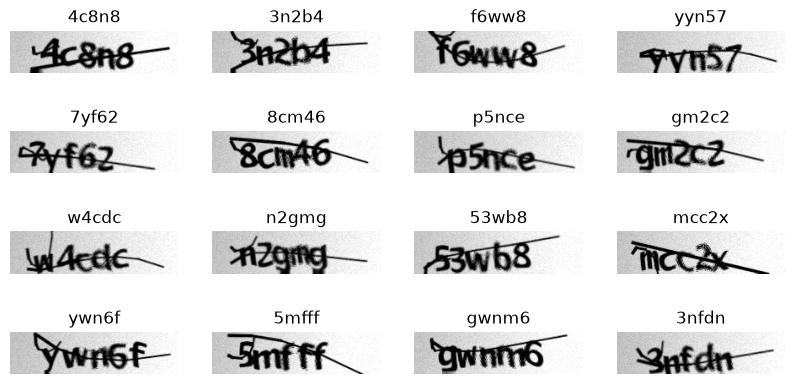

In [8]:
# The training batch shown above, as the model sees it during training
augmented = make_augmentation()(batch_images, training=True)

_, ax = plt.subplots(4, 4, figsize=(10, 5))
for i in range(16):
    ax[i // 4, i % 4].imshow(augmented[i, :, :, 0].numpy().T, cmap="gray", vmin=0, vmax=1)
    ax[i // 4, i % 4].set_title(indices_to_text(batch_labels[i]))
    ax[i // 4, i % 4].axis("off")
plt.show()

The baseline is the keras.io model, unchanged except for returning logits. Training it
on the same split shows whether tuning actually helps.

In [9]:
def build_baseline_model():
    # Inputs to the model
    input_img = layers.Input(
        shape=(img_width, img_height, 1), name="image", dtype="float32"
    )
    labels = layers.Input(name="label", shape=(None,), dtype="int64")

    # First conv block
    x = layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        kernel_initializer="he_normal",
        padding="same",
        name="Conv1",
    )(input_img)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x)

    # Second conv block
    x = layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        kernel_initializer="he_normal",
        padding="same",
        name="Conv2",
    )(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x)

    # One feature vector per time step (image column) for the RNN part of the model
    x = layers.Reshape((x.shape[1], x.shape[2] * x.shape[3]), name="reshape")(x)
    x = layers.Dense(64, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.2)(x)

    # RNNs
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25))(x)

    # The original applies softmax here; ops.ctc_loss applies it itself
    x = layers.Dense(num_classes, name="logits")(x)

    # Add CTC layer for calculating CTC loss at each step
    output = CTCLayer(name="ctc_loss")(labels, x)

    model = keras.models.Model(
        inputs=[input_img, labels], outputs=output, name="ocr_model_baseline"
    )
    model.compile(optimizer=keras.optimizers.Adam())
    return model

The tuned model searches over learning rate, layer sizes, dropout, an optional third conv
block and augmentation. The rest is fixed:

- **ReLU activations.** The first search tuned an activation for every layer, and its best
  trials didn't agree on any of them.
- **AdamW.** It had the best result in the first search. The other optimizers were tested with
  the same learning-rate range, which isn't a fair comparison.
- **Cosine learning-rate decay.** The learning rate falls smoothly over training. Halving it
  when validation loss stalls (`ReduceLROnPlateau`) backfires here, because the loss is nearly
  flat during CTC's initial plateau, so the rate gets cut before the model has learned anything.

In [10]:
def conv_block(x, filters, pool_size, name):
    # Conv -> batch norm -> ReLU -> max-pool
    x = layers.Conv2D(
        filters,
        (3, 3),
        use_bias=False,
        kernel_initializer="he_normal",
        padding="same",
        name=f"{name}_conv",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("relu", name=f"{name}_relu")(x)
    return layers.MaxPooling2D(pool_size, name=f"{name}_pool")(x)


def build_model(hp):
    # Inputs to the model
    input_img = layers.Input(
        shape=(img_width, img_height, 1), name="image", dtype="float32"
    )
    labels = layers.Input(name="label", shape=(None,), dtype="int64")

    x = input_img
    if hp.Boolean("augment"):
        x = make_augmentation()(x)

    filters = hp.Choice("conv_filters", [32, 64])
    x = conv_block(x, filters, (2, 2), name="block1")
    x = conv_block(x, filters * 2, (2, 2), name="block2")
    if hp.Boolean("third_conv_block"):
        # Pool along the height only, so the number of time steps stays the same
        x = conv_block(x, filters * 4, (1, 2), name="block3")

    # One feature vector per time step (image column) for the RNN part of the model
    x = layers.Reshape((x.shape[1], x.shape[2] * x.shape[3]), name="reshape")(x)
    x = layers.Dense(hp.Choice("dense_units", [64, 128]), activation="relu", name="dense1")(x)
    x = layers.Dropout(hp.Float("dropout", min_value=0.1, max_value=0.5, step=0.1))(x)

    # RNNs
    lstm_units = hp.Choice("lstm_units", [64, 128, 256])
    lstm_dropout = hp.Float("lstm_dropout", min_value=0.0, max_value=0.4, step=0.1)
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True, dropout=lstm_dropout)
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(lstm_units // 2, return_sequences=True, dropout=lstm_dropout)
    )(x)

    # Logits over the vocabulary plus the CTC blank
    x = layers.Dense(num_classes, name="logits")(x)

    # Add CTC layer for calculating CTC loss at each step
    output = CTCLayer(name="ctc_loss")(labels, x)

    # Define the model
    model = keras.models.Model(
        inputs=[input_img, labels], outputs=output, name="ocr_model_v2"
    )

    # Below 3e-4 the model can spend most of its epochs on CTC's initial plateau
    learning_rate = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=hp.Float("lr", min_value=3e-4, max_value=3e-3, sampling="log"),
        decay_steps=epochs * len(train_dataset),
    )
    model.compile(optimizer=keras.optimizers.AdamW(learning_rate=learning_rate))
    return model

## Training

First the baseline, trained the same way as on keras.io: up to 100 epochs, stopping
after 10 epochs without a better validation loss.

In [11]:
def early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )


keras.utils.set_random_seed(SEED)
baseline_model = build_baseline_model()
baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stopping()],
    verbose=2,
)

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


52/52 - 7s - 139ms/step - loss: 21.4153 - val_loss: 16.4972
Epoch 2/100
52/52 - 4s - 78ms/step - loss: 16.3993 - val_loss: 16.4472
Epoch 3/100
52/52 - 5s - 99ms/step - loss: 16.3751 - val_loss: 16.4432
Epoch 4/100
52/52 - 5s - 103ms/step - loss: 16.3658 - val_loss: 16.4071
Epoch 5/100
52/52 - 5s - 98ms/step - loss: 16.3694 - val_loss: 16.3719
Epoch 6/100
52/52 - 5s - 98ms/step - loss: 16.3672 - val_loss: 16.4418
Epoch 7/100
52/52 - 5s - 99ms/step - loss: 16.3440 - val_loss: 16.4088
Epoch 8/100
52/52 - 5s - 97ms/step - loss: 16.3438 - val_loss: 16.4259
Epoch 9/100
52/52 - 5s - 98ms/step - loss: 16.3331 - val_loss: 16.3889
Epoch 10/100
52/52 - 5s - 98ms/step - loss: 16.3270 - val_loss: 16.4206
Epoch 11/100
52/52 - 5s - 97ms/step - loss: 16.3224 - val_loss: 16.3447
Epoch 12/100
52/52 - 5s - 98ms/step - loss: 16.3217 - val_loss: 16.3762
Epoch 13/100
52/52 - 5s - 98ms/step - loss: 16.3087 - val_loss: 16.3827
Epoch 14/100
52/52 - 5s - 99ms/step - loss: 16.2805 - val_loss: 16.3514
Epoch 15/10

Then the search, with early stopping on every trial. Results are saved to `tuner_results/`
and reloaded when the cell is re-run.
Delete that folder after changing `build_model`, or the old trials are reused.

In [ ]:
# Search for the hyperparameters with the lowest validation loss
tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective="val_loss",
    max_trials=12,
    num_initial_points=4,
    seed=SEED,
    directory="tuner_results",
    project_name="captcha_ocr",
    overwrite=False,
)
tuner.search_space_summary()
tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stopping()],
    verbose=2,
)
tuner.results_summary(num_trials=5)

Trial 4 Complete [00h 28m 06s]
val_loss: 0.10385076701641083

Best val_loss So Far: 0.10385076701641083
Total elapsed time: 01h 55m 28s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Search: Running Trial #5

Value             |Best Value So Far |Hyperparameter
False             |False             |augment
64                |32                |conv_filters
True              |True              |third_conv_block
128               |128               |dense_units
0.1               |0.5               |dropout
64                |64                |lstm_units
0                 |0                 |lstm_dropout
0.0022044         |0.0005714         |lr

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


52/52 - 47s - 903ms/step - loss: 20.8011 - val_loss: 16.4996
Epoch 2/100
52/52 - 36s - 696ms/step - loss: 16.3743 - val_loss: 16.4525
Epoch 3/100
52/52 - 36s - 700ms/step - loss: 16.3574 - val_loss: 16.3909
Epoch 4/100
52/52 - 36s - 702ms/step - loss: 16.3475 - val_loss: 16.4527
Epoch 5/100
52/52 - 37s - 713ms/step - loss: 16.3489 - val_loss: 16.4146
Epoch 6/100
52/52 - 37s - 709ms/step - loss: 16.3411 - val_loss: 16.4070
Epoch 7/100
52/52 - 38s - 740ms/step - loss: 16.3348 - val_loss: 16.4367
Epoch 8/100
52/52 - 44s - 852ms/step - loss: 16.3336 - val_loss: 16.4281
Epoch 9/100
52/52 - 41s - 783ms/step - loss: 16.3048 - val_loss: 16.4128
Epoch 10/100
52/52 - 40s - 768ms/step - loss: 16.3020 - val_loss: 16.3354
Epoch 11/100
52/52 - 39s - 751ms/step - loss: 16.2794 - val_loss: 16.3604
Epoch 12/100
52/52 - 38s - 726ms/step - loss: 16.2265 - val_loss: 16.2703
Epoch 13/100
52/52 - 36s - 690ms/step - loss: 16.1581 - val_loss: 16.1294
Epoch 14/100
52/52 - 34s - 645ms/step - loss: 16.0717 - val

Rebuild the best configuration and train it from scratch. Continuing to train the tuner's
saved model would start a fresh optimizer on weights that have already converged.

In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp.values)

keras.utils.set_random_seed(SEED)
best_model = build_model(best_hp)
best_model.summary()

history = best_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stopping()],
    verbose=2,
)

## Evaluation

- **Exact match:** the fraction of captchas read completely correctly.
- **CER (character error rate):** character edits needed to fix the predictions, divided by the number of true characters.

The validation set chose the hyperparameters and the stopping epoch, so treat the test
columns as the real result.

In [ ]:
def edit_distance(a, b):
    # Levenshtein distance: the fewest insertions, deletions and substitutions turning a into b
    previous = list(range(len(b) + 1))
    for i, char_a in enumerate(a, start=1):
        current = [i]
        for j, char_b in enumerate(b, start=1):
            current.append(
                min(previous[j] + 1, current[j - 1] + 1, previous[j - 1] + (char_a != char_b))
            )
        previous = current
    return previous[-1]


def to_prediction_model(model):
    # Keep image -> logits; drop the label input and the CTC layer
    return keras.models.Model(model.inputs[0], model.get_layer(name="logits").output)


# A utility function to decode the output of the network
def decode_batch_predictions(pred):
    sequence_lengths = ops.full((ops.shape(pred)[0],), ops.shape(pred)[1], dtype="int32")
    # Use greedy search. For complex tasks, you can use beam search
    decoded, _ = ops.ctc_decode(
        pred, sequence_lengths, strategy="greedy", mask_index=blank_index
    )
    return [indices_to_text(indices) for indices in decoded[0]]


def predict_dataset(prediction_model, dataset):
    predictions, truths = [], []
    for batch in dataset:
        predictions += decode_batch_predictions(
            prediction_model.predict(batch["image"], verbose=0)
        )
        truths += [indices_to_text(label) for label in batch["label"]]
    return predictions, truths


def evaluate(prediction_model, dataset):
    predictions, truths = predict_dataset(prediction_model, dataset)
    pairs = list(zip(predictions, truths))
    exact_match = np.mean([pred == truth for pred, truth in pairs])
    cer = sum(edit_distance(pred, truth) for pred, truth in pairs) / sum(map(len, truths))
    return exact_match, cer


baseline_prediction_model = to_prediction_model(baseline_model)
prediction_model = to_prediction_model(best_model)

rows = {}
for name, model in [("Baseline (keras.io)", baseline_prediction_model), ("Tuned", prediction_model)]:
    val_exact, val_cer = evaluate(model, validation_dataset)
    test_exact, test_cer = evaluate(model, test_dataset)
    rows[name] = {
        "Val exact match": val_exact,
        "Val CER": val_cer,
        "Test exact match": test_exact,
        "Test CER": test_cer,
    }
pd.DataFrame(rows).T.style.format("{:.1%}")

## Inference

The original keras.io model is hosted on [Hugging Face Hub](https://huggingface.co/keras-io/ocr-for-captcha),
with a demo on [Hugging Face Spaces](https://huggingface.co/spaces/keras-io/ocr-for-captcha).

The test-set predictions below are titled `prediction / truth`. Misread captchas are shown
first, in red.

In [ ]:
test_predictions, test_truths = predict_dataset(prediction_model, test_dataset)
test_images = np.concatenate([batch["image"].numpy() for batch in test_dataset])

# Misread captchas first
order = sorted(range(len(test_truths)), key=lambda i: test_predictions[i] == test_truths[i])

_, ax = plt.subplots(4, 4, figsize=(15, 5))
for plot_index, i in enumerate(order[:16]):
    img = (test_images[i, :, :, 0] * 255).astype(np.uint8).T
    correct = test_predictions[i] == test_truths[i]
    ax[plot_index // 4, plot_index % 4].imshow(img, cmap="gray")
    ax[plot_index // 4, plot_index % 4].set_title(
        f"{test_predictions[i]} / {test_truths[i]}", color="black" if correct else "tab:red"
    )
    ax[plot_index // 4, plot_index % 4].axis("off")
plt.show()

errors = [(truth, pred) for pred, truth in zip(test_predictions, test_truths) if pred != truth]
print(f"{len(errors)} of {len(test_truths)} test captchas misread")
for truth, pred in errors:
    print(f"  {truth} -> {pred}")

## Save the model

In [ ]:
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)
prediction_model.save(model_dir / "captcha_ocr.keras")
# The model outputs vocabulary indices, so the vocabulary is needed to read its predictions
(model_dir / "captcha_ocr_vocabulary.json").write_text(
    json.dumps(char_to_num.get_vocabulary())
)